<a href="https://colab.research.google.com/github/DLiu7/MousePathPlotter/blob/main/Mouse_Path_Plotter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

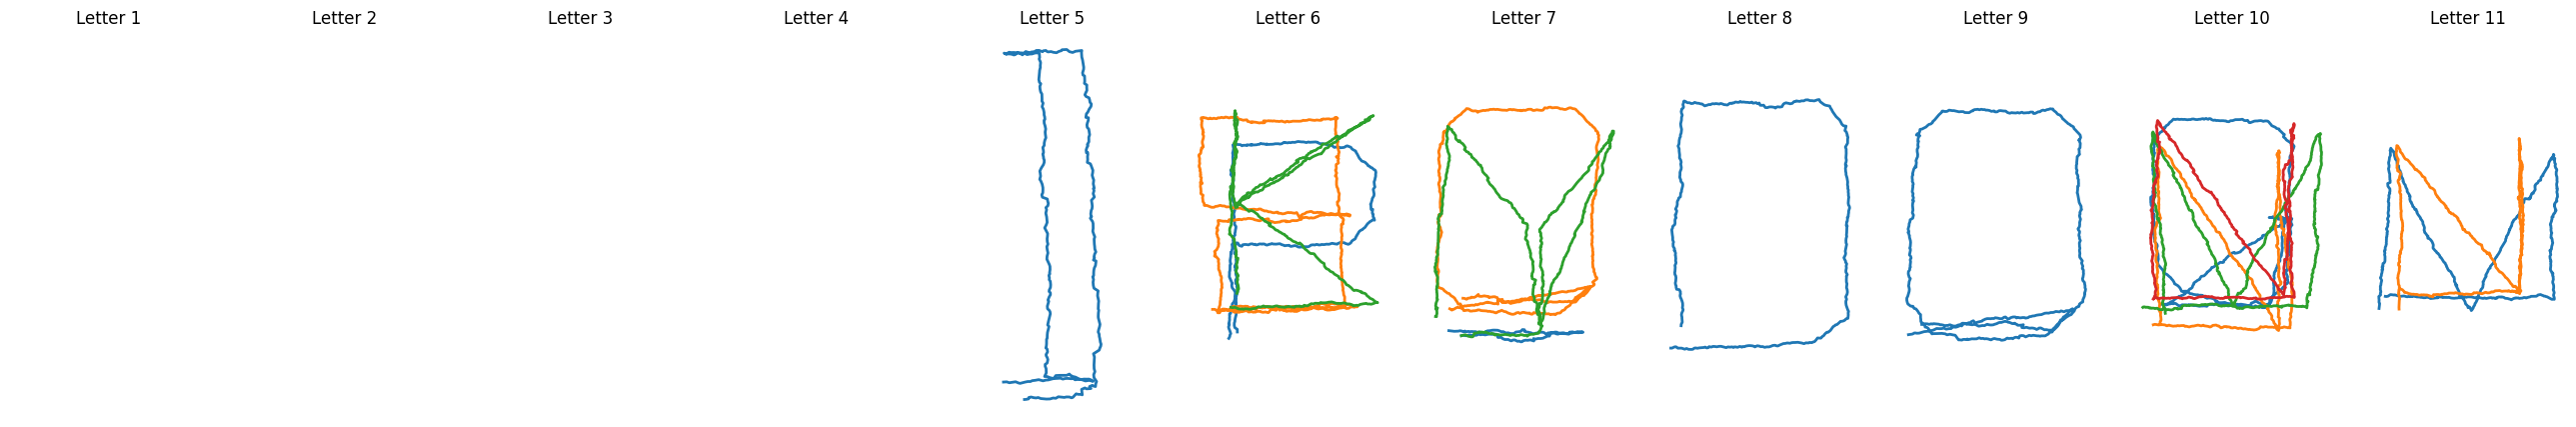

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def segment_strokes(file_path, threshold=0.5, min_gap=10, n_letters=None):
    df = pd.read_csv(file_path)
    df["speed"] = np.sqrt(df["velocity_x"]**2 + df["velocity_y"]**2)

    strokes = []
    cx, cy = 0.0, 0.0
    cur_x, cur_y = [cx], [cy]
    pause_count = 0

    for _, row in df.iterrows():
        vx, vy, speed = row["velocity_x"], row["velocity_y"], row["speed"]
        cx += vx
        cy += vy

        if speed < threshold:
            pause_count += 1
        else:
            pause_count = 0

        if pause_count > min_gap:
            if len(cur_x) > 1:
                strokes.append((np.array(cur_x), np.array(cur_y)))
            cur_x, cur_y = [cx], [cy]
            pause_count = 0
        else:
            cur_x.append(cx)
            cur_y.append(cy)

    if len(cur_x) > 1:
        strokes.append((np.array(cur_x), np.array(cur_y)))

    # Normalize
    all_x = np.hstack([s[0] for s in strokes])
    all_y = np.hstack([s[1] for s in strokes])
    min_x, min_y = all_x.min(), all_y.min()
    strokes = [((xs - min_x), (ys - min_y)) for xs, ys in strokes]

    # Sort by x centroid
    centroids = [xs.mean() for xs, ys in strokes]
    order = np.argsort(centroids)
    strokes = [strokes[i] for i in order]

    # Group strokes into letters by large horizontal gaps
    gaps = np.diff(sorted(centroids))
    if n_letters is None:
        # Heuristic: split at gaps larger than mean+std
        cutoff = gaps.mean() + gaps.std()
        split_indices = np.where(gaps > cutoff)[0] + 1
    else:
        # Choose n_letters groups
        split_indices = np.array_split(np.arange(len(strokes)), n_letters)

    # Make groups
    groups = []
    if isinstance(split_indices, np.ndarray):
        start = 0
        for idx in split_indices:
            groups.append(strokes[start:idx])
            start = idx
        groups.append(strokes[start:])
    else:
        for group in split_indices:
            groups.append([strokes[i] for i in group])

    return groups

def plot_letters(groups):
    n = len(groups)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 5))
    if n == 1:
        axes = [axes]
    for i, group in enumerate(groups):
        for xs, ys in group:
            axes[i].plot(xs, ys, linewidth=2)
        axes[i].invert_yaxis()
        axes[i].axis("equal")
        axes[i].set_title(f"Letter {i+1}")
        axes[i].axis("off")
    plt.show()

# Run
groups = segment_strokes("mouse_velocities.csv")
plot_letters(groups)
